In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, accuracy_score, 
                             f1_score, recall_score, precision_score, confusion_matrix, classification_report, 
                             precision_recall_fscore_support, roc_curve)

In [3]:
df_x = pd.read_csv('Data/X.csv')
df_y = pd.read_csv('Data/target.csv')

df = pd.concat([df_x, df_y], axis=1)

df.head()

,funded_amnt,interest_rate,monthly_payment,grade,emp_title,emp_length,home_ownership_status,annual_income,verification_status,loan_purpose,...,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq,disbursement_method,loan_term_months,issue_date_month,issue_date_year,region_code,earliest_cr_line_month,earliest_cr_line_year,y
0,2500,13.56,84.92,C1,Chef,10+ years,RENT,55000.0,Not Verified,debt_consolidation,...,NaN,NaN,Cash,36,Dec,2018,1,Apr,2001,0
1,30000,18.94,777.23,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,debt_consolidation,...,NaN,NaN,Cash,60,Dec,2018,7,Jun,1987,0
2,5000,17.97,180.69,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,debt_consolidation,...,NaN,NaN,Cash,36,Dec,2018,4,Apr,2011,0
3,4000,18.94,146.51,D2,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,debt_consolidation,...,NaN,NaN,Cash,36,Dec,2018,9,Feb,2006,0
4,30000,16.14,731.78,C4,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,debt_consolidation,...,NaN,NaN,Cash,60,Dec,2018,2,Dec,2000,0


In [374]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
funded_amnt,2139643.0,14782.296100,9033.085915,5.000000e+02,8000.000000,12250.00,20000.000,4.000000e+04
interest_rate,2139643.0,13.059646,4.795935,5.310000e+00,9.490000,12.62,15.880,3.099000e+01
monthly_payment,2139643.0,439.304234,263.363421,4.930000e+00,249.130000,373.22,581.600,1.719830e+03
annual_income,2139643.0,78987.774254,115041.933734,1.896000e+03,47400.000000,65299.00,95000.000,1.100000e+08
dept_paym_income_ratio,2139643.0,18.093687,8.425314,-1.000000e+00,11.780000,17.60,24.040,4.996000e+01
num_30+_delinq_in_2yrs,2139643.0,0.309936,0.872271,0.000000e+00,0.000000,0.00,0.000,5.800000e+01
num_inq_in_6mths,2139643.0,0.587227,0.894615,0.000000e+00,0.000000,0.00,1.000,3.300000e+01
mths_since_last_delinq,1048646.0,34.503356,21.896744,0.000000e+00,16.000000,31.00,50.000,2.260000e+02
num_open_credit_lines,2139643.0,11.640173,5.643363,0.000000e+00,8.000000,11.00,14.000,1.010000e+02
num_derogatory_pub_rec,2139643.0,0.199921,0.577406,0.000000e+00,0.000000,0.00,0.000,8.600000e+01


We are removing variables that may cause data leakage, as they provide indirect information about the target class (delinquents).

In [4]:
cols_leakage = [
    'princ_rec',
    'interest_rec', 
    'late_fees_rec',
    'paym_rec_for_tot_amnt_fund',
    'remaining_princ_for_tot_amnt_fund'
]

df = df.drop(columns=cols_leakage)

In [376]:
df['y'].value_counts()

y
0    1859927
1     279716
Name: count, dtype: int64

There is a clear class imbalance:

In [377]:
desbalanceo = (df[df['y'] == 1].count() / df[df['y'] == 0].count()) * 100
print(f"Hay un desbalanceo de clases de {desbalanceo.values[0]:.2f}% morosos sobre el total.")

Hay un desbalanceo de clases de 15.04% morosos sobre el total.


In [5]:
df.rename(columns={
    'y': 'moroso'
}, inplace=True)

In [379]:
df.isnull().sum().sort_values(ascending=False).head(15)

mths_since_recent_bankcard_delinq     1643502
mths_since_recent_revol_delinq        1433891
mths_since_last_delinq                1090997
mths_since_last_installment_acc_op     905256
bal_to_cred_lim                        865775
num_open_trades_in_6mths               865656
num_installment_acc_op_in_24mths       865656
num_installment_acc_op_in_12mths       865656
num_rev_trades_op_in_12mths            865656
num_rev_trades_op_in_24mths            865656
num_inq                                865656
max_bal_owed                           865656
emp_title                              148527
emp_length                             130346
interest_rate                               0
dtype: int64

In [380]:
df.isnull().mean().sort_values(ascending=False).head(15)

mths_since_recent_bankcard_delinq     0.768120
mths_since_recent_revol_delinq        0.670154
mths_since_last_delinq                0.509897
mths_since_last_installment_acc_op    0.423087
bal_to_cred_lim                       0.404635
num_open_trades_in_6mths              0.404580
num_installment_acc_op_in_24mths      0.404580
num_installment_acc_op_in_12mths      0.404580
num_rev_trades_op_in_12mths           0.404580
num_rev_trades_op_in_24mths           0.404580
num_inq                               0.404580
max_bal_owed                          0.404580
emp_title                             0.069417
emp_length                            0.060920
interest_rate                         0.000000
dtype: float64

Since the variables with NaN > 0.15%—such as months since last delinquency or number of accounts installed in 12/24 months—have overlapping NaNs, I will fill the NaNs up to 'num_inq' with 0.

In [6]:
columnas = ['mths_since_recent_bankcard_delinq', 
            'mths_since_recent_revol_delinq',
            'mths_since_last_delinq',
            'mths_since_last_installment_acc_op',
            'bal_to_cred_lim',
            'num_installment_acc_op_in_12mths',
            'num_installment_acc_op_in_24mths',
            'num_open_trades_in_6mths',
            'num_rev_trades_op_in_12mths',
            'max_bal_owed',
            'num_rev_trades_op_in_24mths',
            'num_inq']

df[columnas] = df[columnas].fillna(0)

In [382]:
df.isnull().mean().sort_values(ascending=False).head()

emp_title          0.069417
emp_length         0.060920
funded_amnt        0.000000
monthly_payment    0.000000
interest_rate      0.000000
dtype: float64

In [383]:
df['emp_length'].value_counts()

emp_length
10+ years    714363
2 years      194813
3 years      172765
< 1 year     167859
1 year       142335
5 years      133519
4 years      130607
6 years       98444
7 years       89299
8 years       88624
9 years       76669
Name: count, dtype: int64

We create the necessary financial variables, feature engineering:

In [7]:
# 1
df['LGD'] = 100 * df['max_bal_owed'] / df['funded_amnt']

# 2
df['EAD'] = df['funded_amnt']

# 3
df.rename(columns={'moroso': 'PD'}, inplace=True)

In [8]:
df = df[df['LGD'] < 300]

In [9]:
# We are defining the targets, because in boxplots, PD=1 would be detected as an outlier. Also we have capped LGD < 300.
target_cols = ['PD', 'LGD', 'EAD']

num_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
            if col not in target_cols]

num_cols

['funded_amnt',
 'interest_rate',
 'monthly_payment',
 'annual_income',
 'dept_paym_income_ratio',
 'num_30+_delinq_in_2yrs',
 'num_inq_in_6mths',
 'mths_since_last_delinq',
 'num_open_credit_lines',
 'num_derogatory_pub_rec',
 'total_credit_revolving_bal',
 'used_credit_share',
 'tot_num_credit_lines',
 'num_open_trades_in_6mths',
 'num_installment_acc_op_in_12mths',
 'num_installment_acc_op_in_24mths',
 'mths_since_last_installment_acc_op',
 'num_rev_trades_op_in_12mths',
 'num_rev_trades_op_in_24mths',
 'max_bal_owed',
 'bal_to_cred_lim',
 'num_inq',
 'num_inq_in_12mths',
 'mths_since_recent_bankcard_delinq',
 'mths_since_recent_revol_delinq',
 'loan_term_months',
 'issue_date_year',
 'region_code',
 'earliest_cr_line_year']

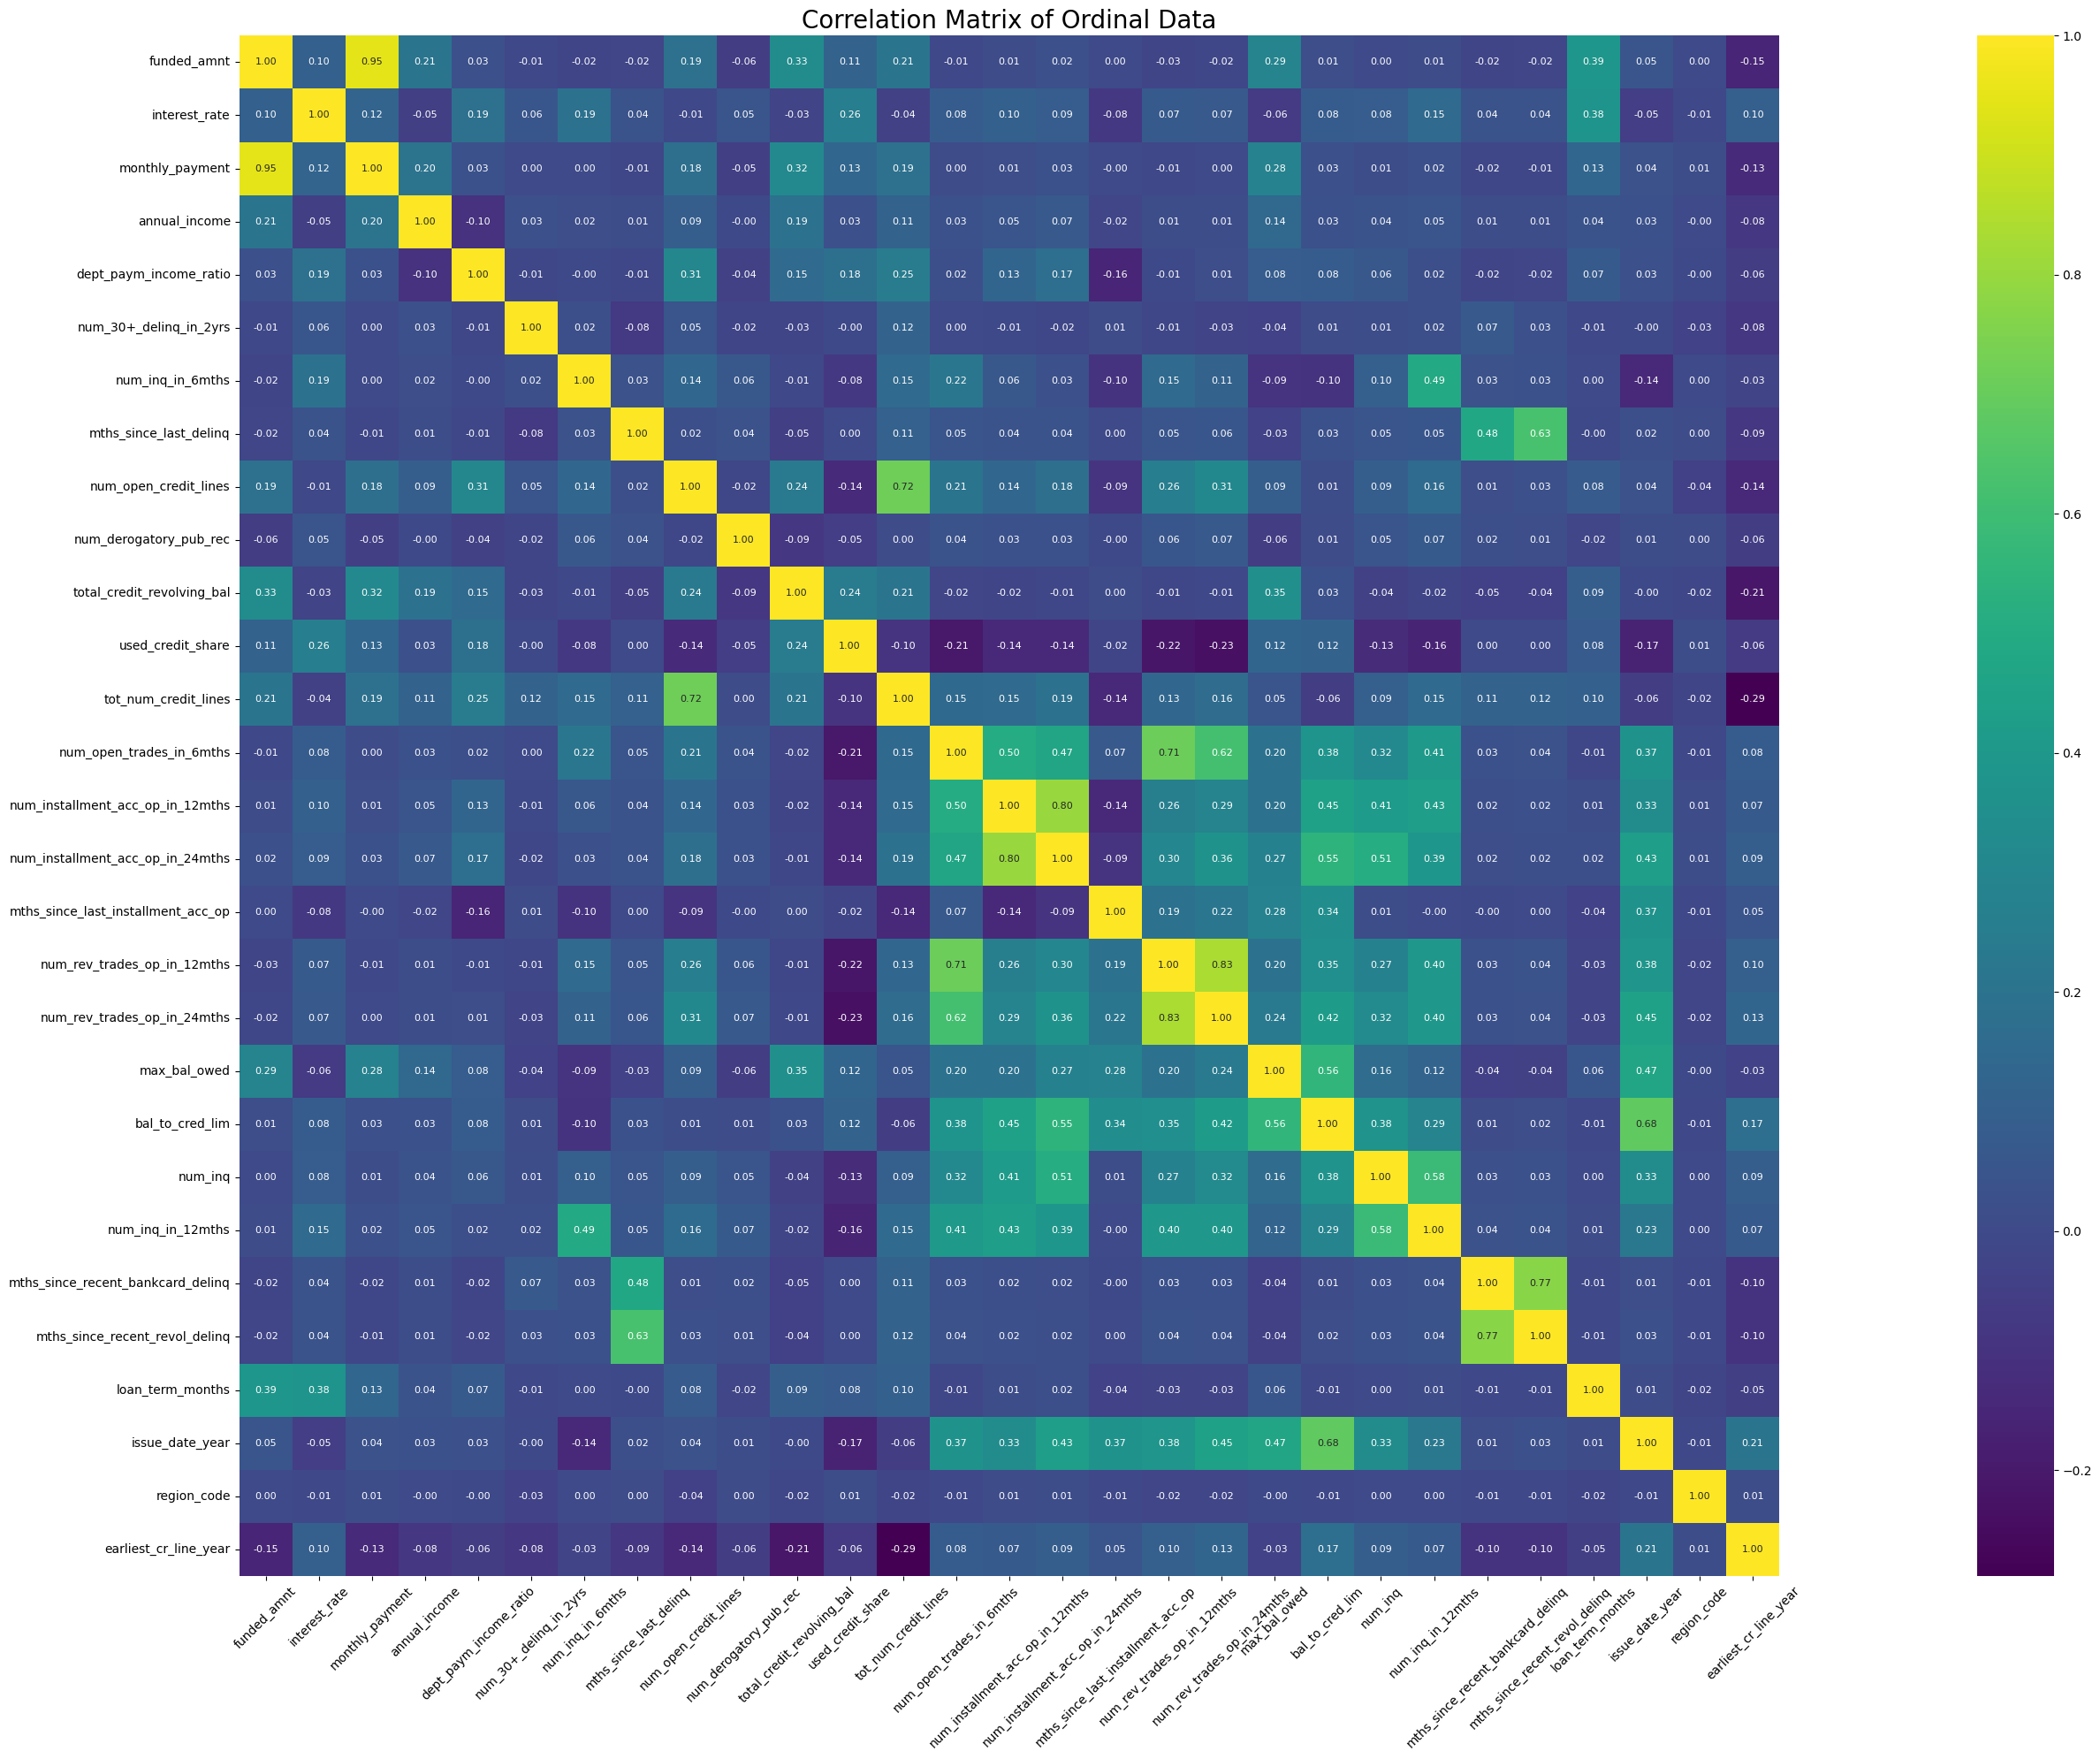

In [ ]:
plt.figure(figsize=(45, 20))
sns.heatmap(df[num_cols].corr(), 
            cmap="viridis", 
            fmt=".2f",
            annot=True,
            annot_kws={"size": 8},
            square=True,
            cbar=True)
plt.title('Correlation Matrix of Ordinal Data', fontsize=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [387]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['grade', 'emp_title', 'emp_length', 'home_ownership_status',
       'verification_status', 'loan_purpose', 'addr_state',
       'initial_list_status', 'disbursement_method', 'issue_date_month',
       'earliest_cr_line_month'],
      dtype='object')

In [ ]:
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} categorías únicas")

grade: 35 categorías únicas
emp_title: 494981 categorías únicas
emp_length: 11 categorías únicas
home_ownership_status: 4 categorías únicas
verification_status: 3 categorías únicas
loan_purpose: 14 categorías únicas
addr_state: 51 categorías únicas
initial_list_status: 2 categorías únicas
disbursement_method: 2 categorías únicas
issue_date_month: 12 categorías únicas
earliest_cr_line_month: 12 categorías únicas


We are dropping high-cardinality features to clean noise and reduce bias in the training set.

In [389]:
df = df.drop(columns=['emp_title'])

In [390]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['grade', 'emp_length', 'home_ownership_status', 'verification_status',
       'loan_purpose', 'addr_state', 'initial_list_status',
       'disbursement_method', 'issue_date_month', 'earliest_cr_line_month'],
      dtype='object')

In [391]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2123651 entries, 0 to 2139642
Data columns (total 42 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   funded_amnt                         int64  
 1   interest_rate                       float64
 2   monthly_payment                     float64
 3   grade                               object 
 4   emp_length                          object 
 5   home_ownership_status               object 
 6   annual_income                       float64
 7   verification_status                 object 
 8   loan_purpose                        object 
 9   addr_state                          object 
 10  dept_paym_income_ratio              float64
 11  num_30+_delinq_in_2yrs              int64  
 12  num_inq_in_6mths                    int64  
 13  mths_since_last_delinq              float64
 14  num_open_credit_lines               int64  
 15  num_derogatory_pub_rec              int64  
 16  total

In [392]:
df['PD']

0          0
1          0
2          0
3          0
4          0
          ..
2139638    0
2139639    0
2139640    0
2139641    0
2139642    0
Name: PD, Length: 2123651, dtype: int64

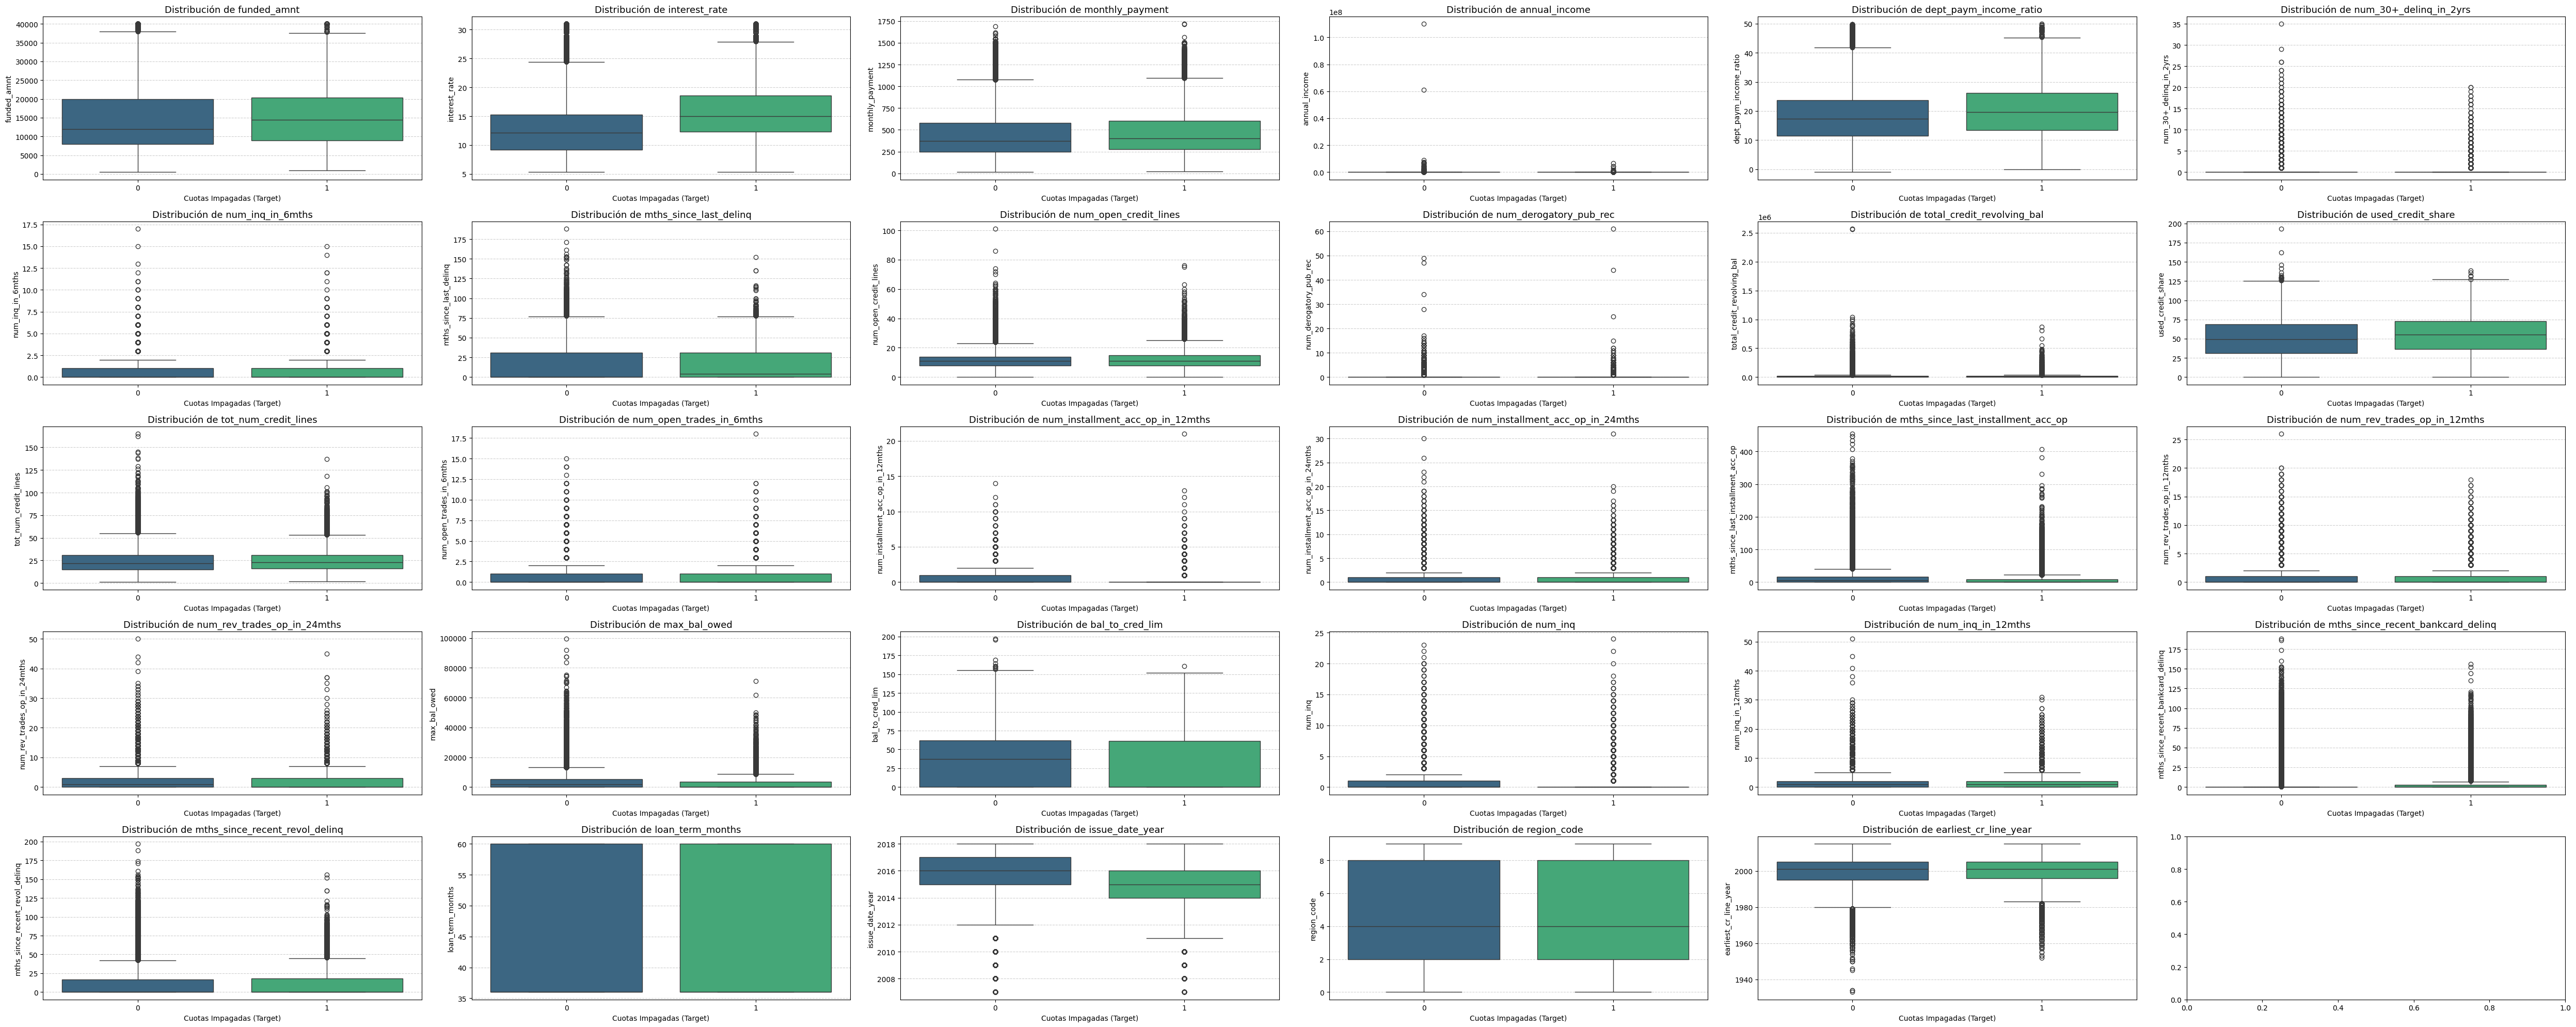

In [279]:
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(50, 20))
axes = axes.flatten()

for (i, col) in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        x='PD', 
        y=col, 
        ax=axes[i], 
        palette='viridis',
        orient='v',
        hue='PD',
        legend=False
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('Cuotas Impagadas (Target)')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
def IQR(df, columnas):
    df_clean = df.copy()
    
    for col in columnas:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        outliers_inf = (df_clean[col] < limite_inferior).sum()
        outliers_sup = (df_clean[col] > limite_superior).sum()
        
        df_clean[col] = np.where(df_clean[col] < limite_inferior, Q1, df_clean[col])
        df_clean[col] = np.where(df_clean[col] > limite_superior, Q3, df_clean[col])
        
        print(f"Columna '{col}': {outliers_inf} outliers inferiores -> {Q1:.2f} & {outliers_sup} outliers superiores -> {Q3:.2f}")
        
    return df_clean

df_clean = IQR(df, num_cols)

Columna 'funded_amnt': 0 outliers inferiores -> 8000.00 & 27185 outliers superiores -> 20000.00
Columna 'interest_rate': 0 outliers inferiores -> 9.49 & 39946 outliers superiores -> 15.88
Columna 'monthly_payment': 0 outliers inferiores -> 251.58 & 69002 outliers superiores -> 583.89
Columna 'annual_income': 0 outliers inferiores -> 47210.50 & 99793 outliers superiores -> 95000.00
Columna 'dept_paym_income_ratio': 0 outliers inferiores -> 11.75 & 1618 outliers superiores -> 24.00
Columna 'num_30+_delinq_in_2yrs': 0 outliers inferiores -> 0.00 & 399725 outliers superiores -> 0.00
Columna 'num_inq_in_6mths': 0 outliers inferiores -> 0.00 & 91833 outliers superiores -> 1.00
Columna 'mths_since_last_delinq': 0 outliers inferiores -> 0.00 & 29603 outliers superiores -> 31.00
Columna 'num_open_credit_lines': 0 outliers inferiores -> 8.00 & 80309 outliers superiores -> 14.00
Columna 'num_derogatory_pub_rec': 0 outliers inferiores -> 0.00 & 339840 outliers superiores -> 0.00
Columna 'total_cre

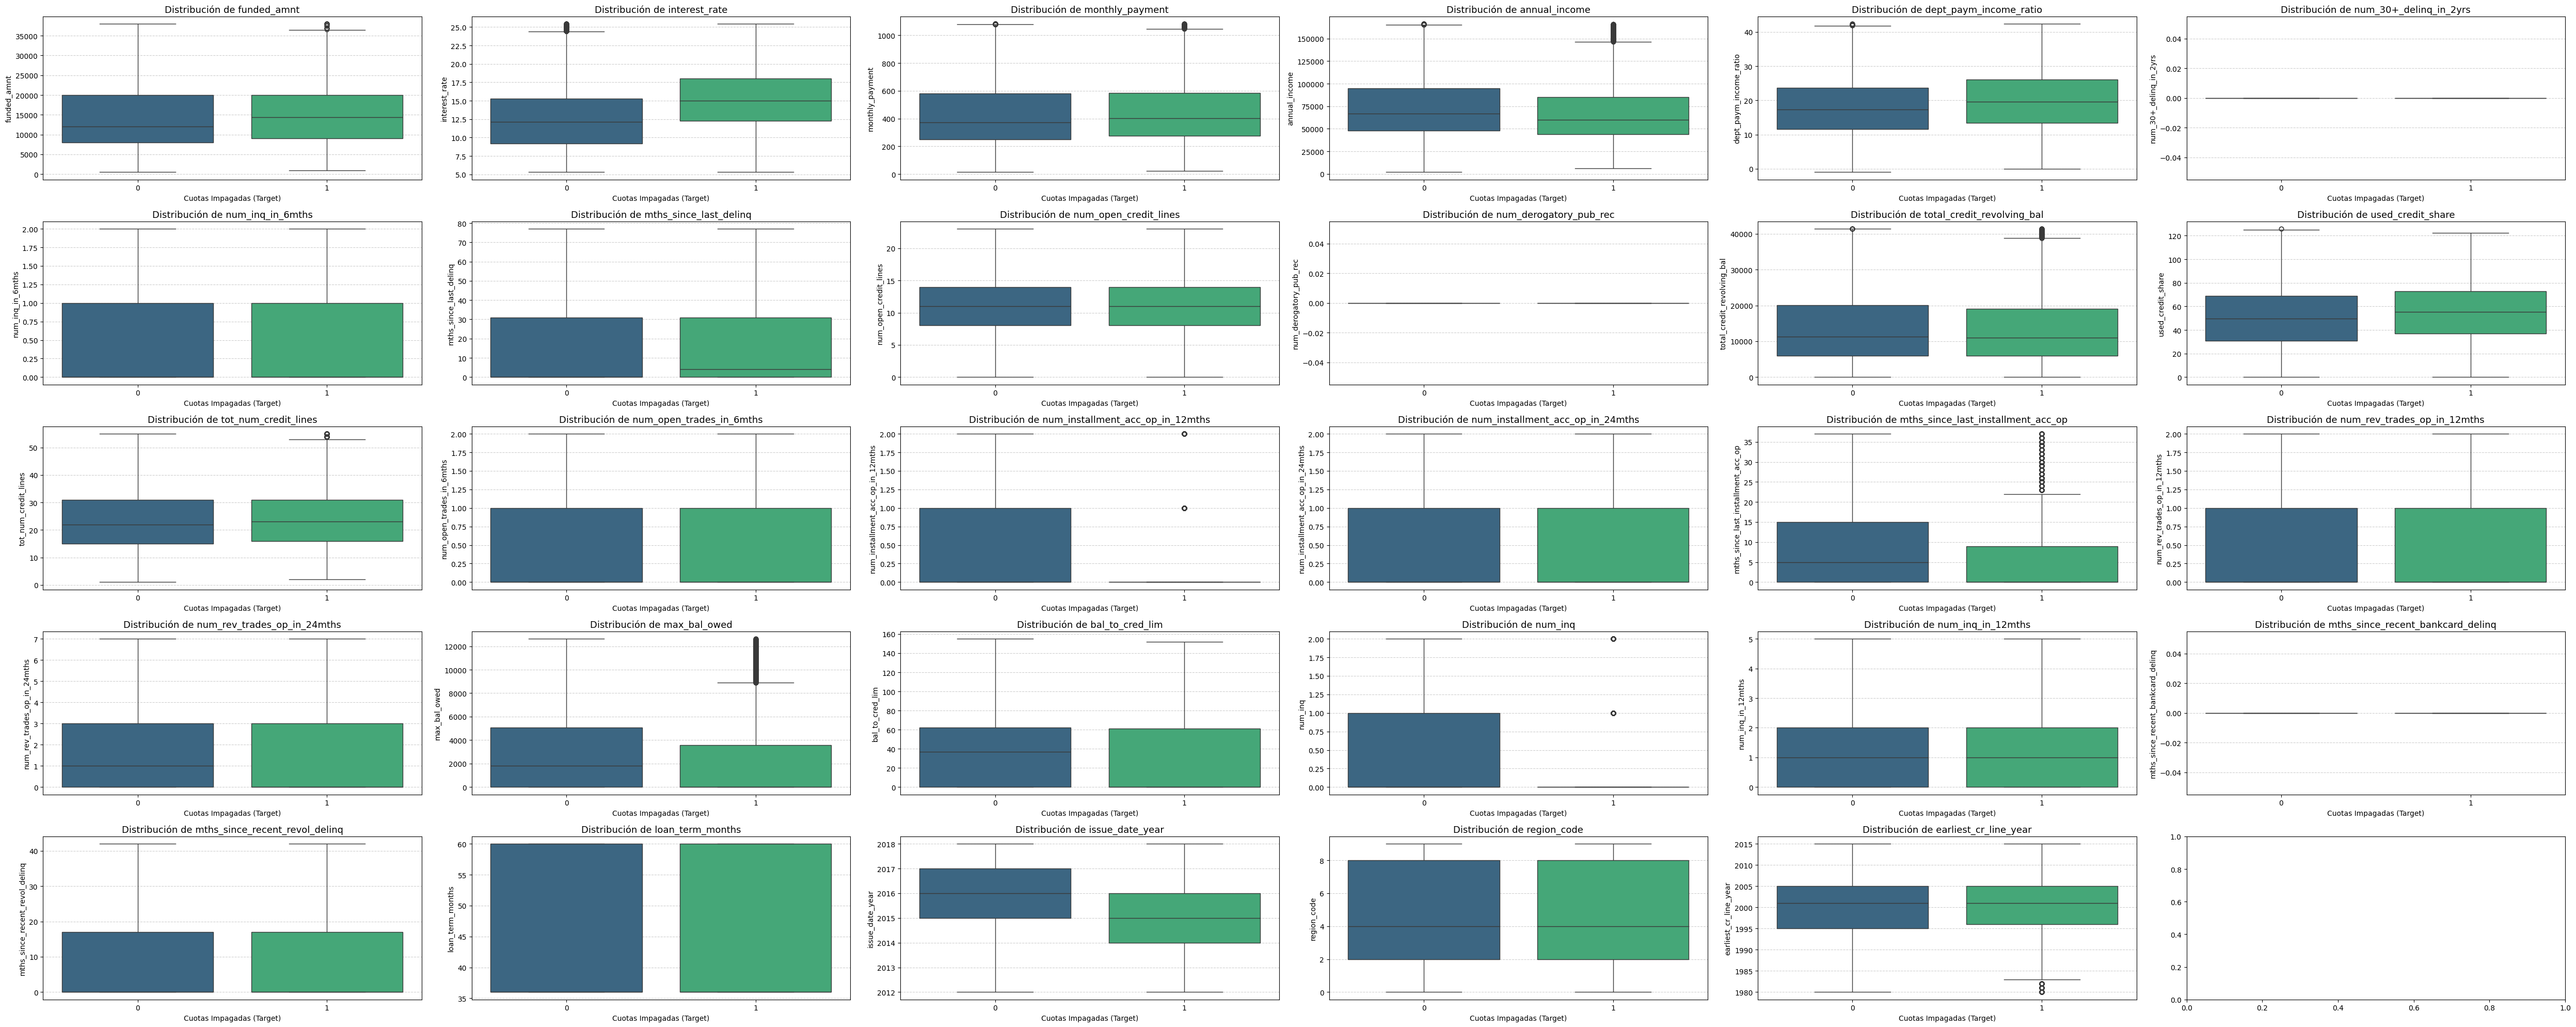

In [281]:
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(50, 20))
axes = axes.flatten()

for (i, col) in enumerate(num_cols):
    sns.boxplot(
        data=df_clean, 
        x='PD', 
        y=col, 
        ax=axes[i], 
        palette='viridis',
        orient='v',
        hue='PD',
        legend=False
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('Cuotas Impagadas (Target)')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [393]:
cat_cols

Index(['grade', 'emp_length', 'home_ownership_status', 'verification_status',
       'loan_purpose', 'addr_state', 'initial_list_status',
       'disbursement_method', 'issue_date_month', 'earliest_cr_line_month'],
      dtype='object')

One-hot encoding:

In [395]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [396]:
df.columns

Index(['funded_amnt', 'interest_rate', 'monthly_payment', 'annual_income',
       'dept_paym_income_ratio', 'num_30+_delinq_in_2yrs', 'num_inq_in_6mths',
       'mths_since_last_delinq', 'num_open_credit_lines',
       'num_derogatory_pub_rec',
       ...
       'earliest_cr_line_month_Dec', 'earliest_cr_line_month_Feb',
       'earliest_cr_line_month_Jan', 'earliest_cr_line_month_Jul',
       'earliest_cr_line_month_Jun', 'earliest_cr_line_month_Mar',
       'earliest_cr_line_month_May', 'earliest_cr_line_month_Nov',
       'earliest_cr_line_month_Oct', 'earliest_cr_line_month_Sep'],
      dtype='object', length=168)

In [397]:
df.head()

,funded_amnt,interest_rate,monthly_payment,annual_income,dept_paym_income_ratio,num_30+_delinq_in_2yrs,num_inq_in_6mths,mths_since_last_delinq,num_open_credit_lines,num_derogatory_pub_rec,...,earliest_cr_line_month_Dec,earliest_cr_line_month_Feb,earliest_cr_line_month_Jan,earliest_cr_line_month_Jul,earliest_cr_line_month_Jun,earliest_cr_line_month_Mar,earliest_cr_line_month_May,earliest_cr_line_month_Nov,earliest_cr_line_month_Oct,earliest_cr_line_month_Sep
0,2500,13.56,84.92,55000.0,18.24,0,1,0.0,9,1,...,False,False,False,False,False,False,False,False,False,False
1,30000,18.94,777.23,90000.0,26.52,0,0,71.0,13,1,...,False,False,False,False,True,False,False,False,False,False
2,5000,17.97,180.69,59280.0,10.51,0,0,0.0,8,0,...,False,False,False,False,False,False,False,False,False,False
3,4000,18.94,146.51,92000.0,16.74,0,0,0.0,10,0,...,False,True,False,False,False,False,False,False,False,False
4,30000,16.14,731.78,57250.0,26.35,0,0,0.0,12,0,...,True,False,False,False,False,False,False,False,False,False


In [398]:
df['PD'].value_counts()

PD
0    1845023
1     278628
Name: count, dtype: int64

In [399]:
df.head()

,funded_amnt,interest_rate,monthly_payment,annual_income,dept_paym_income_ratio,num_30+_delinq_in_2yrs,num_inq_in_6mths,mths_since_last_delinq,num_open_credit_lines,num_derogatory_pub_rec,...,earliest_cr_line_month_Dec,earliest_cr_line_month_Feb,earliest_cr_line_month_Jan,earliest_cr_line_month_Jul,earliest_cr_line_month_Jun,earliest_cr_line_month_Mar,earliest_cr_line_month_May,earliest_cr_line_month_Nov,earliest_cr_line_month_Oct,earliest_cr_line_month_Sep
0,2500,13.56,84.92,55000.0,18.24,0,1,0.0,9,1,...,False,False,False,False,False,False,False,False,False,False
1,30000,18.94,777.23,90000.0,26.52,0,0,71.0,13,1,...,False,False,False,False,True,False,False,False,False,False
2,5000,17.97,180.69,59280.0,10.51,0,0,0.0,8,0,...,False,False,False,False,False,False,False,False,False,False
3,4000,18.94,146.51,92000.0,16.74,0,0,0.0,10,0,...,False,True,False,False,False,False,False,False,False,False
4,30000,16.14,731.78,57250.0,26.35,0,0,0.0,12,0,...,True,False,False,False,False,False,False,False,False,False


In [400]:
df.shape

(2123651, 168)

In [402]:
df.to_csv('cleaned_data.csv', index=False)